In [1]:
import matplotlib.pyplot as plt
import muon
import numpy as np
import requests
import scanpy as sc
import scipy
import scvi
import seaborn as sns
import torch
import re
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
torch.set_float32_matmul_precision("high")

/opt/anaconda3/lib/python3.13/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


# Read Data

In [3]:
mdata = muon.read_h5mu("../../data/tonsil/tonsil_pp.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [4]:
scvi.model.TOTALVI.setup_mudata(mdata, modalities={'rna_layer': 'RNA',
                                                   'protein_layer': 'Protein'
                                                   })

# Run TotalVI

In [17]:
model = scvi.model.TOTALVI(mdata)

INFO     Computing empirical prior initialization for protein background.                                          


In [18]:
model.train(early_stopping = True)

/opt/anaconda3/lib/python3.13/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does n

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 2023.627. Signaling Trainer to stop.


In [19]:
rna = mdata.mod["RNA"]
protein = mdata.mod["Protein"]

In [20]:
# arbitrarily store latent in rna modality
TOTALVI_LATENT_KEY = "X_totalVI"
rna.obsm[TOTALVI_LATENT_KEY] = model.get_latent_representation()

In [21]:
rna_denoised, protein_denoised = model.get_normalized_expression(n_samples=25, return_mean=True)
rna.layers["denoised_rna"] = rna_denoised
protein.layers["denoised_protein"] = protein_denoised

protein.layers["protein_foreground_prob"] = 100 * model.get_protein_foreground_probability(
    n_samples=25, return_mean=True
)
parsed_protein_names = [re.sub(pattern = "\.[ATGC]*$", repl = "", string = p) for p in protein.var_names]
protein.var["clean_names"] = parsed_protein_names
mdata.update()

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [22]:
TOTALVI_CLUSTERS_KEY = "leiden_totalVI"
TOTALVI_CLUSTERS_KEY_LOUVAIN = "louvain_totalVI"
TOTALVI_CLUSTERS_KEY_KMEANS = "kmeans_totalVI"

sc.pp.neighbors(rna, use_rep=TOTALVI_LATENT_KEY)
sc.tl.umap(rna)
sc.tl.leiden(rna, key_added=TOTALVI_CLUSTERS_KEY, resolution= 0.7)
sc.tl.louvain(rna, key_added=TOTALVI_CLUSTERS_KEY_LOUVAIN, resolution = 0.7)

kmeans_mod = KMeans(n_clusters=5, random_state=0).fit(rna.obsm['X_totalVI'])
rna.obs[TOTALVI_CLUSTERS_KEY_KMEANS] = kmeans_mod.labels_.astype(str)

In [23]:
mdata.update()

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [27]:
model.save("../results/vanilla_totalVI.pt", overwrite=True)

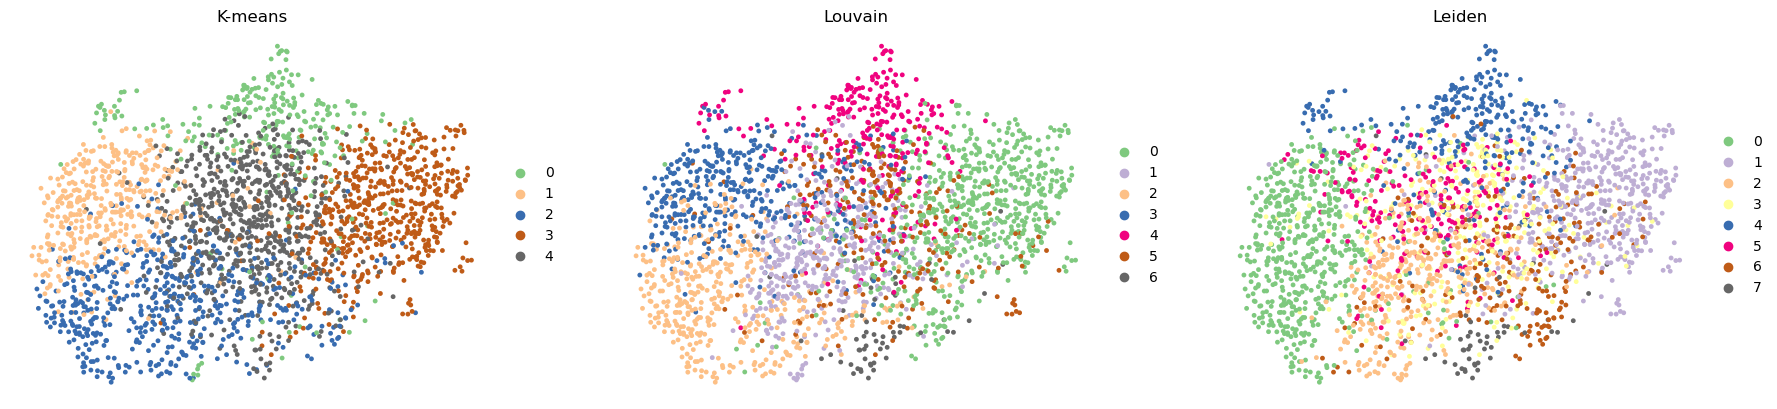

In [25]:
rna_umap_plot = muon.pl.embedding(
    mdata,
    basis="RNA:X_umap",
    color=[f"RNA:{TOTALVI_CLUSTERS_KEY_KMEANS}",f"RNA:{TOTALVI_CLUSTERS_KEY_LOUVAIN}", f"RNA:{TOTALVI_CLUSTERS_KEY}"],
    frameon = False,
    palette = 'Accent',
    title = ['K-means', 'Louvain', 'Leiden'],
    return_fig=True
)

In [93]:
rna_umap_plot.savefig("../results/vanilla_totalVI_UMAP.pdf")
rna_umap_plot.savefig("../results/vanilla_totalVI_UMAP.png", dpi = 300)

# Moran's I

In [32]:
moran_i = sc.metrics.morans_i(rna, obsm="X_totalVI")

In [33]:
pd.DataFrame(data = {'Moran_I_vanilla_totalVI': moran_i}).to_csv("../results/Moran_I_metrics_vanilla_totalVI.csv", index = False)

# DE

In [34]:
de_df = model.differential_expression(
    groupby="RNA:leiden_totalVI", delta=0.5, batch_correction=True
)
de_df.head(5)

DE...:   0%|          | 0/6 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
CD7.TGGATTCCCGGACTT_protein,0.6976,0.3024,0.835895,4.061483,1.919587,0.00001,0.5,1.299072,1.287592,1.571468,...,1.554455,0.834734,0.695898,0.496919,NaN,NaN,False,0 vs Rest,0,Rest
CD2.TACGATTTGTCAGGG_protein,0.6572,0.3428,0.650841,6.226691,3.254164,0.00001,0.5,1.395247,1.120941,1.858956,...,2.384724,1.292437,0.831683,0.626891,NaN,NaN,False,0 vs Rest,0,Rest
CD3.CTCATTGTAACTCCT_protein,0.6518,0.3482,0.626961,86.888718,50.110817,0.00001,0.5,0.877791,0.819885,0.899539,...,34.912306,18.338375,1.000000,1.000000,NaN,NaN,False,0 vs Rest,0,Rest
CD49a.ACTGATGGACTCAGA_protein,0.6248,0.3752,0.509972,47.952263,29.028410,0.00001,0.5,0.806354,0.767320,0.853349,...,19.189533,10.838095,1.000000,0.996639,NaN,NaN,False,0 vs Rest,0,Rest
CD45RB.AGATGGGACTCACCA_protein,0.6128,0.3872,0.459097,9.096354,5.619122,0.00001,0.5,0.781569,0.726952,0.906035,...,3.490806,2.131653,0.944837,0.832493,NaN,NaN,False,0 vs Rest,0,Rest


In [35]:
filtered_pro = {}
filtered_rna = {}
cats = rna.obs[TOTALVI_CLUSTERS_KEY].cat.categories
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]
    cell_type_df = cell_type_df.sort_values("lfc_median", ascending=False)

    cell_type_df = cell_type_df[cell_type_df.lfc_median > 0]

    pro_rows = cell_type_df.index.str.contains("protein")
    data_pro = cell_type_df.iloc[pro_rows]
    data_pro = data_pro[data_pro["bayes_factor"] > 0.7]

    data_rna = cell_type_df.iloc[~pro_rows]
    data_rna = data_rna[data_rna["bayes_factor"] > 3]
    data_rna = data_rna[data_rna["non_zeros_proportion1"] > 0.1]

    filtered_pro[c] = data_pro.index.tolist()[:3]
    filtered_rna[c] = data_rna.index.tolist()[:2]

In [36]:
sc.tl.dendrogram(rna, groupby=TOTALVI_CLUSTERS_KEY, use_rep=TOTALVI_LATENT_KEY)

In [37]:
[item for sublist in list(filtered_rna.values()) for item in sublist]

['SMARCA4']

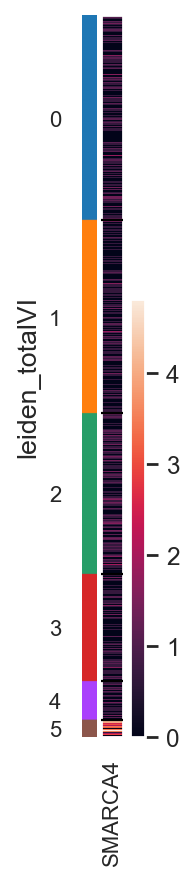

In [38]:
sc.pl.heatmap(rna, var_names = [item for sublist in list(filtered_rna.values()) for item in sublist], groupby=TOTALVI_CLUSTERS_KEY, use_raw = False, log = True)

In [52]:
# For protein data
protein.obs[TOTALVI_CLUSTERS_KEY] = rna.obs[TOTALVI_CLUSTERS_KEY]
protein.obsm[TOTALVI_LATENT_KEY] = rna.obsm[TOTALVI_LATENT_KEY]
sc.tl.dendrogram(protein, groupby=TOTALVI_CLUSTERS_KEY, use_rep=TOTALVI_LATENT_KEY)

In [53]:
filtered_pro_cleaned = [item for sublist in list(filtered_pro.values()) for item in sublist]
filtered_pro_cleaned = [re.sub('\.[ATGC]*_protein', repl = '', string = item) for item in filtered_pro_cleaned]

In [54]:
filtered_pro_cleaned

['CD7',
 'CD31',
 'CD66b',
 'CD324..E.Cadherin.',
 'CD55',
 'CD106',
 'CD73..Ecto.5..nucleotidase.']

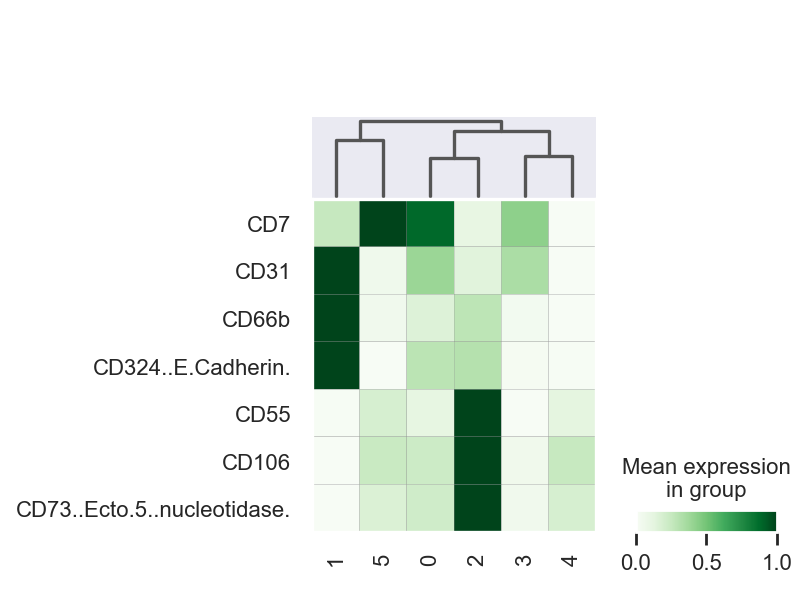

In [55]:
sc.pl.matrixplot(
    protein,
    filtered_pro_cleaned,
    groupby=TOTALVI_CLUSTERS_KEY,
    gene_symbols="clean_names",
    dendrogram=True,
    swap_axes=True,
    layer="denoised_protein",
    cmap="Greens",
    standard_scale="var"
)

In [ ]:
# GOD I hate the python version of scRNAseq analysis it's so messy

## Wilcoxon Rank-Sum

- To be able to compare with our spatial totalVI that doesn't use the totalVI model

In [57]:
# Normalizing to median total counts
sc.pp.normalize_total(rna)
# Logarithmize the data
sc.pp.log1p(rna)

In [65]:
plt.style.use('default')

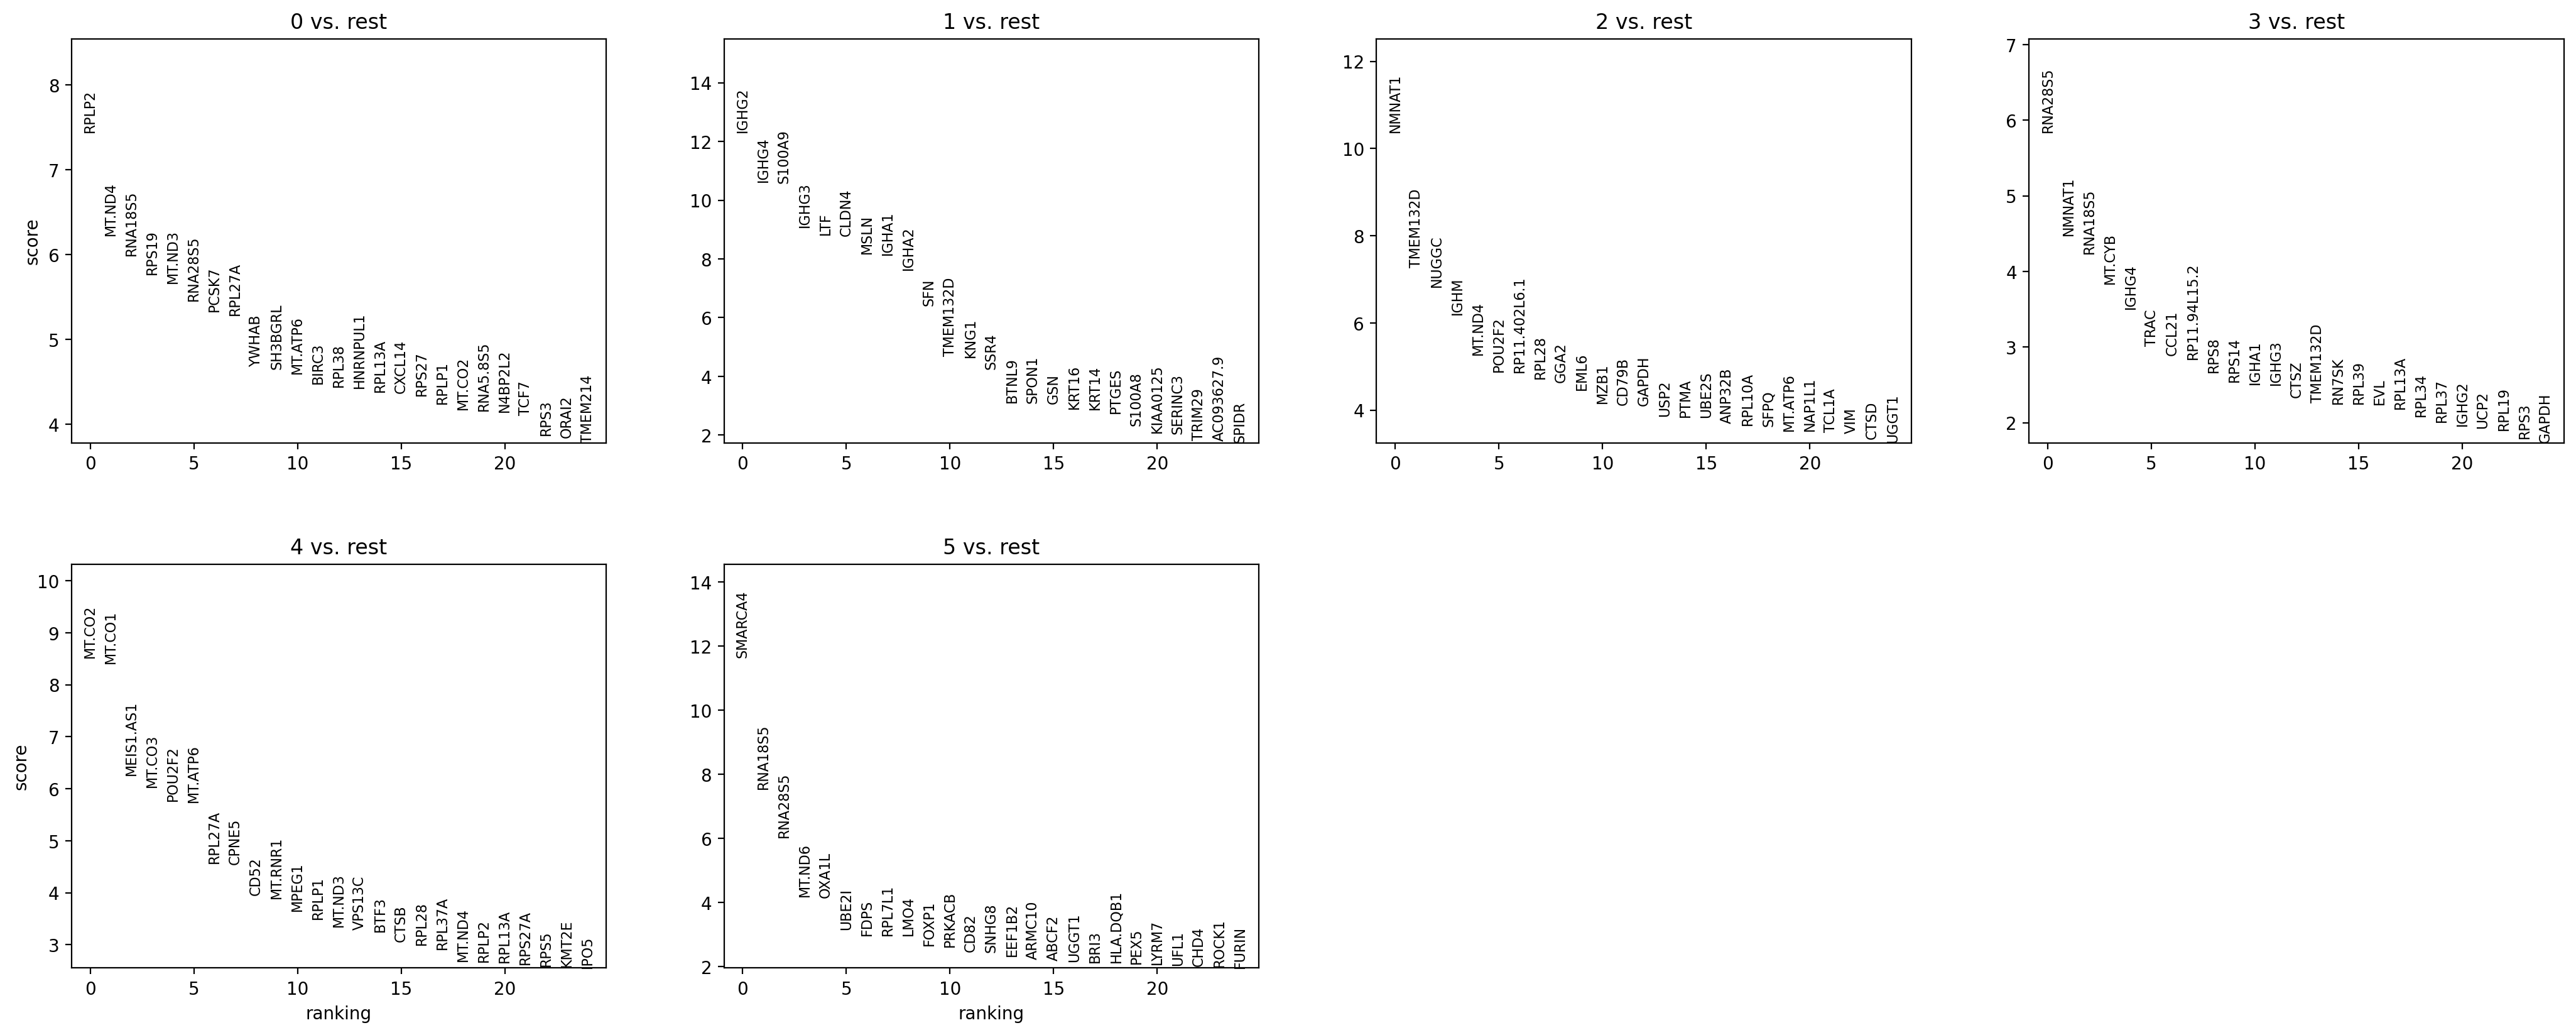

In [66]:
sc.tl.rank_genes_groups(rna, 'leiden_totalVI', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(rna, n_genes=25, sharey=False, key="wilcoxon")

In [98]:
rna_dotplot = sc.pl.rank_genes_groups_dotplot(rna,
                                              n_genes=8, 
                                              values_to_plot="logfoldchanges",
                                              key="wilcoxon",
                                              groupby="leiden_totalVI",
                                              cmap = "RdBu_r",
                                              vmin = -1.25,
                                              vcenter = 0,
                                              vmax =1.25,
                                              return_fig = True
                                              )

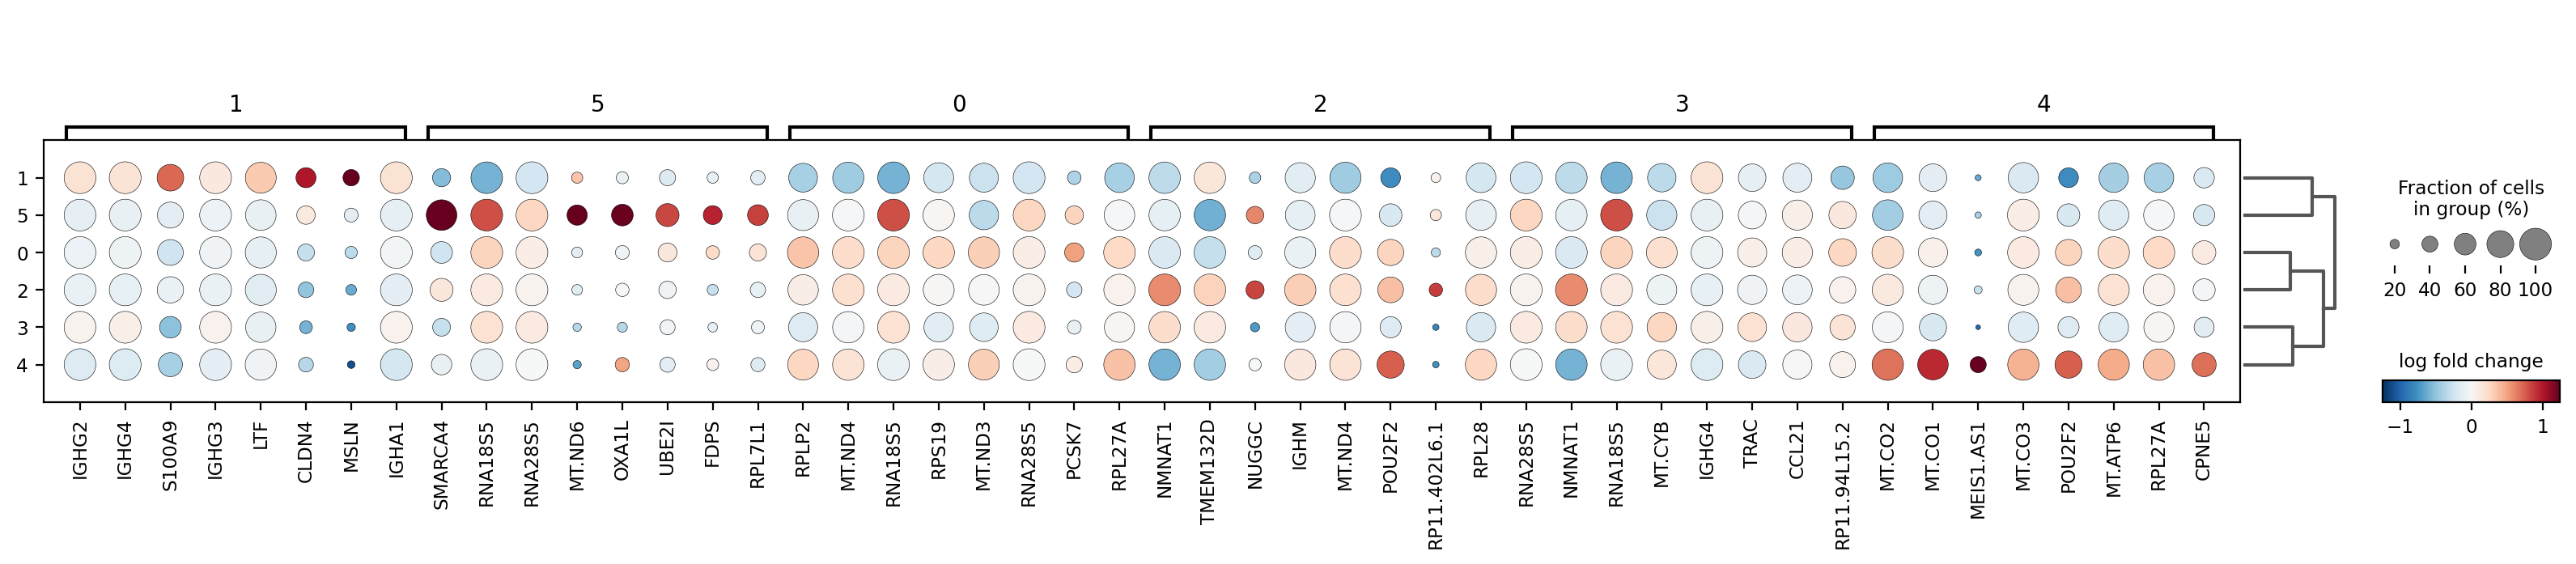

In [99]:
rna_dotplot.show()

In [100]:
rna_dotplot.fig.set_size_inches(w = 16, h = 6)
rna_dotplot.fig.savefig("../results/vanilla_totalVI_RNA_DE_dotplot.pdf", bbox_inches="tight")